## Tugas Proyek Kelompok 2 (P2)
### Penerapan Clustering untuk Segmentasi Pelanggan E-Commerce

####Kelompok 2
Kode Kelompok: KAL2

1. Galih Najwa Pradipta (245150200111009)
2. Muhammad Fahmi Yakhsya (245150200111011)
3. Anasya Laili Rahmadani (245150200111013)
4. Nayla Masyitha Ramadhani (245150200111016)
5. Hassan Nashrallah (245150200111025)

### 1) Import Dataset
Dataset yang kami pilih adalah Mall Customer Dataset yang diperoleh dari Kaggle.

In [ ]:
! wget -O Mall_Customers.csv "https://gist.githubusercontent.com/ryanorsinger/cb1222e506c1266b9cc808143ddbab82/raw/mall_customers.csv"

--2026-05-10 03:28:45--  https://gist.githubusercontent.com/ryanorsinger/cb1222e506c1266b9cc808143ddbab82/raw/mall_customers.csv
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4177 (4.1K) [text/plain]
Saving to: ‘Mall_Customers.csv’

Mall_Customers.csv  100%[===================>]   4.08K  --.-KB/s    in 0s      

2026-05-10 03:28:45 (41.1 MB/s) - ‘Mall_Customers.csv’ saved [4177/4177]



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

##2) Eksplorasi dan Praproses Data

In [ ]:
df = pd.read_csv("Mall_Customers.csv")
print("===== 5 Data Pertama =====")
print(df.head())

print("\n===== Shape Dataset =====")
print(df.shape)

print("\n===== Informasi Dataset =====")
print(df.info())

print("\n===== Statistik Dataset =====")
print(df.describe(include="all"))

print("\n===== Missing Value =====")
print(df.isnull().sum())

===== 5 Data Pertama =====
   customer_id  gender  age  annual_income  spending_score
0            1    Male   19             15              39
1            2    Male   21             15              81
2            3  Female   20             16               6
3            4  Female   23             16              77
4            5  Female   31             17              40

===== Shape Dataset =====
(200, 5)

===== Informasi Dataset =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     200 non-null    int64 
 1   gender          200 non-null    object
 2   age             200 non-null    int64 
 3   annual_income   200 non-null    int64 
 4   spending_score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

===== Statistik Dataset =====
        customer_id  gender         age  annual_income

#### Mengecek Outlier

In [ ]:

numerical_cols = ['age', 'annual_income', 'spending_score']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n{col}:")
    print(f"  Lower bound: {lower_bound}, Upper bound: {upper_bound}")
    print(f"  Number of outliers: {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Outlier values: {outliers[col].tolist()}")


age:
  Lower bound: -1.625, Upper bound: 79.375
  Number of outliers: 0

annual_income:
  Lower bound: -13.25, Upper bound: 132.75
  Number of outliers: 2
  Outlier values: [137, 137]

spending_score:
  Lower bound: -22.625, Upper bound: 130.375
  Number of outliers: 0


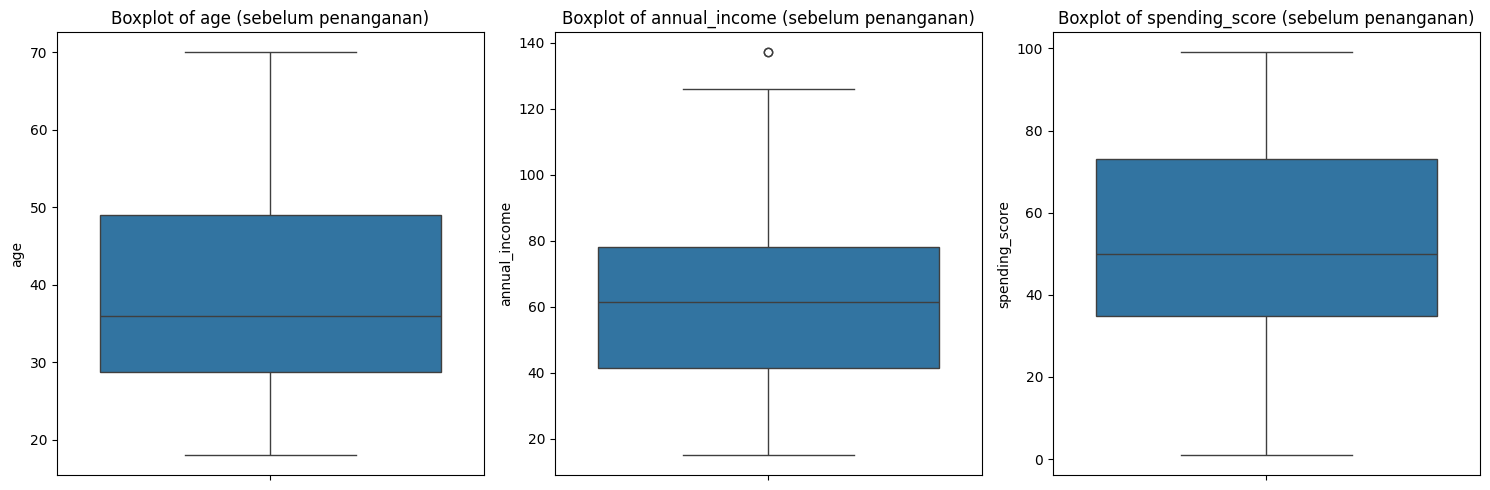

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col} (sebelum penanganan)')

plt.tight_layout()
plt.show()

#### Encoding

In [ ]:
print("Gender value counts:")
print(df['gender'].value_counts())

le = LabelEncoder()
df['gender_label'] = le.fit_transform(df['gender'])
print(f"\nLabel Encoding: Male={le.transform(['Male'])[0]}, Female={le.transform(['Female'])[0]}")

Gender value counts:
gender
Female    112
Male       88
Name: count, dtype: int64

Label Encoding: Male=1, Female=0


#### Penanganan Outlier dan Scaling


##### K-Means

In [ ]:
from sklearn.preprocessing import MinMaxScaler

df_kmeans = df.copy()

df_kmeans['annual_income'] = df_kmeans['annual_income'].clip(upper=132)

scaler = MinMaxScaler()
df_kmeans[['age', 'annual_income', 'spending_score']] = scaler.fit_transform(
    df_kmeans[['age', 'annual_income', 'spending_score']]
)

print("df_kmeans sample:\n", df_kmeans[['age', 'annual_income', 'spending_score']].head(3))

df_kmeans sample:
         age  annual_income  spending_score
0  0.019231       0.000000        0.387755
1  0.057692       0.000000        0.816327
2  0.038462       0.008547        0.051020


##### DBscan

In [ ]:
from sklearn.preprocessing import RobustScaler

df_dbscan = df.copy()
scaler_robust = RobustScaler()
df_dbscan[['age', 'annual_income', 'spending_score']] = scaler_robust.fit_transform(
    df_dbscan[['age', 'annual_income', 'spending_score']]
)

print("df_dbscan sample:\n", df_dbscan[['age', 'annual_income', 'spending_score']].head(3))

df_dbscan sample:
         age  annual_income  spending_score
0 -0.839506      -1.273973       -0.287582
1 -0.740741      -1.273973        0.810458
2 -0.790123      -1.246575       -1.150327


####Visualisasi Setelah Penanganan

###### K-Means

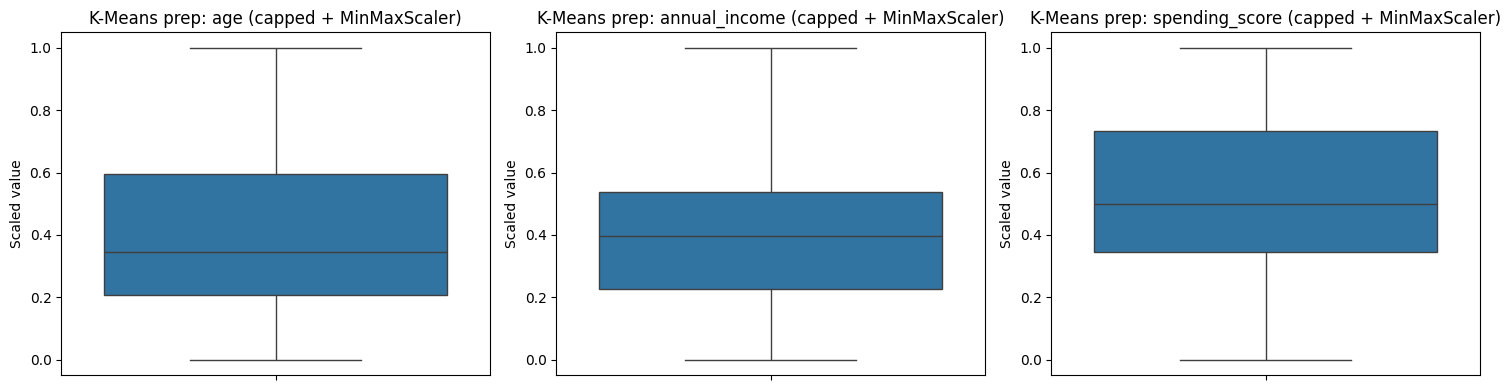

In [ ]:
features_visualize_Kmeans = ['age', 'annual_income', 'spending_score']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(features_visualize_Kmeans):
    sns.boxplot(y=df_kmeans[col], ax=axes[i])
    axes[i].set_title(f'K-Means prep: {col} (capped + MinMaxScaler)')
    axes[i].set_ylabel('Scaled value')
plt.tight_layout()
plt.show()

###### DBScan

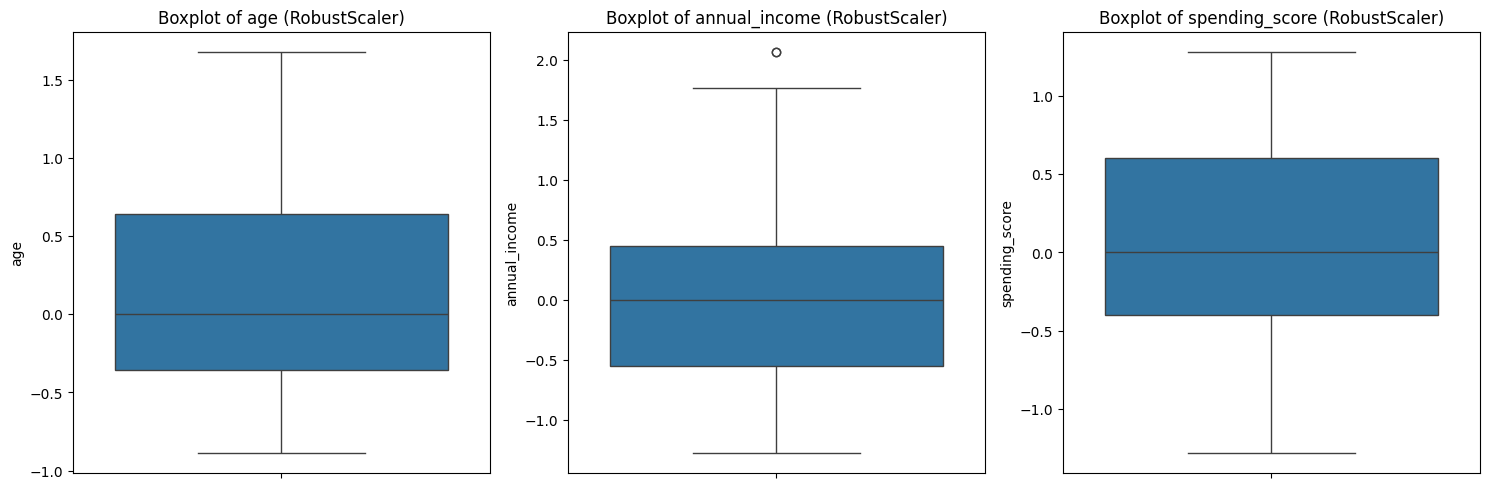

In [ ]:
features_visualize_db = ['age', 'annual_income', 'spending_score']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(features_visualize_db):
    sns.boxplot(y=df_dbscan[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col} (RobustScaler)')
plt.tight_layout()
plt.show()

##3) Feature Engineering & Reduksi

#### Seleksi Fitur

Fitur yang tidak akan digunakan untuk clustering adalah 'customer_id' dan 'gender'. Customer ID bersifat unik untuk setiap pelanggan, dan tidak menggambarkan perilaku atau karakteristik pelanggan. Jika kita menyertakan Customer ID, algoritma akan menganggap setiap pelanggan unik yang mana dapat mengacaukan hasil cluster.

Sementara itu, fitur Gender yang awalnya dimiliki oleh dataset sudah di-encode menjadi angka yang disimpan pada kolom baru bernama 'gender_label'. Karena gender_label sudah berupa fitur numerik, kolom asli Genre yang berupa kategorikal tidak lagi diperlukan untuk clustering.

In [ ]:
features_kmeans = df_kmeans.drop(columns=['customer_id', 'gender', 'gender_label'], axis=1)
X_kmeans = features_kmeans[['age', 'annual_income', 'spending_score']].values

features_dbscan = df_dbscan.drop(columns=['customer_id', 'gender', 'gender_label'], axis=1)
X_dbscan = features_dbscan[['age', 'annual_income', 'spending_score']].values

print(f"Shape X_kmeans: {X_kmeans.shape}")
print(f"Shape X_dbscan: {X_dbscan.shape}")

Shape X_kmeans: (200, 3)
Shape X_dbscan: (200, 3)


####Korelasi Antar Fitur

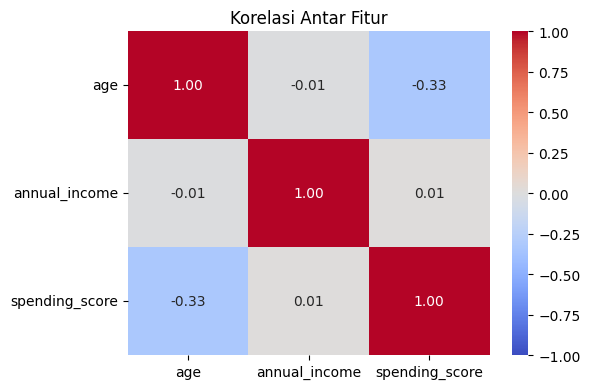

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['age', 'annual_income', 'spending_score']].corr(),
            annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

## 4) Model K-Means

### Menentukan Jumlah Cluster

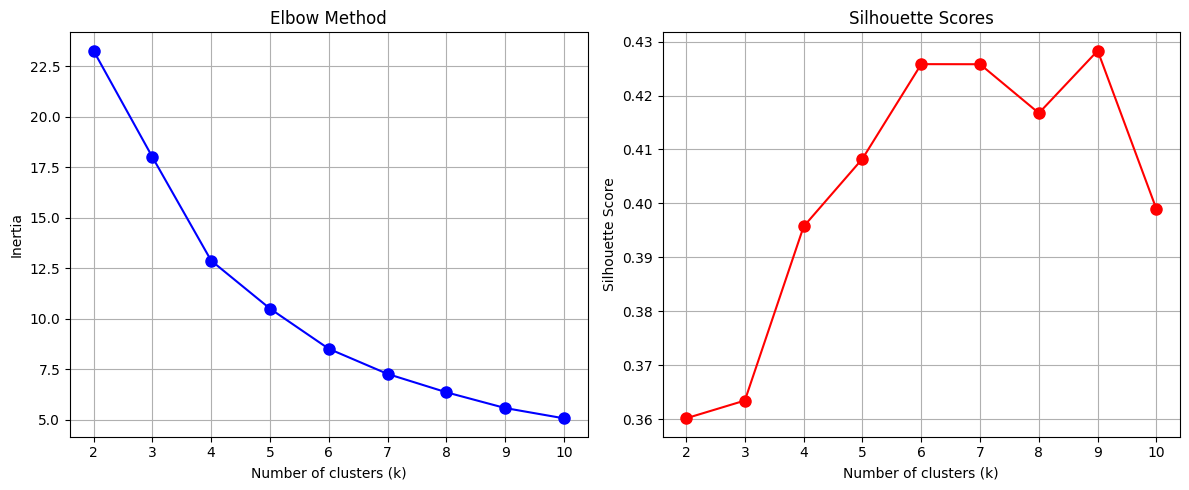

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_list = []
silhouette_list = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_kmeans)
    inertia_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(X_kmeans, labels))

# Plot Elbow Method
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K_range, inertia_list, 'bo-', markersize=8)
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1,2,2)
plt.plot(K_range, silhouette_list, 'ro-', markersize=8)
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

### Pelatihan Model K-Means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

k_optimal = 6  # dari elbow method = 5-6 dan silhouette = 6-7

kmeans_final = KMeans(
    n_clusters=k_optimal,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

labels_kmeans = kmeans_final.fit_predict(X_kmeans)

print(f"K-Means selesai dilatih (k={k_optimal})")
print(f"Jumlah iterasi konvergensi : {kmeans_final.n_iter_}")
print(f"\nDistribusi anggota per cluster:")
unique, counts = np.unique(labels_kmeans, return_counts=True)
for cl, ct in zip(unique, counts):
    print(f"  Cluster {cl} : {ct} pelanggan")

K-Means selesai dilatih (k=6)
Jumlah iterasi konvergensi : 7

Distribusi anggota per cluster:
  Cluster 0 : 40 pelanggan
  Cluster 1 : 43 pelanggan
  Cluster 2 : 19 pelanggan
  Cluster 3 : 30 pelanggan
  Cluster 4 : 23 pelanggan
  Cluster 5 : 45 pelanggan


### Metriks Evaluasi Internal

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

inertia_km = kmeans_final.inertia_
sil_km = silhouette_score(X_kmeans, labels_kmeans)
db_km = davies_bouldin_score(X_kmeans, labels_kmeans)
ch_km = calinski_harabasz_score(X_kmeans, labels_kmeans)

print(f"=== Metrik K-Means ===")
print()
print(f"Inertia (WCSS)           : {inertia_km:.4f}")
print(f"Silhouette Score         : {sil_km:.4f}")
print(f"Davies-Bouldin Index     : {db_km:.4f}")
print(f"Calinski-Harabasz Index  : {ch_km:.4f}")

=== Metrik K-Means ===

Inertia (WCSS)           : 8.5178
Silhouette Score         : 0.4258
Davies-Bouldin Index     : 0.8511
Calinski-Harabasz Index  : 134.7462


### Visualisasi PCA dengan Centroid

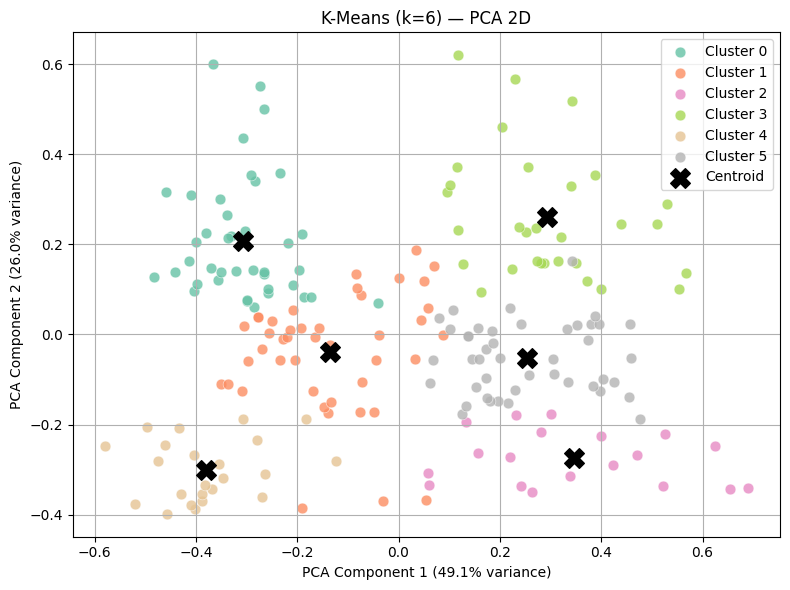

In [ ]:
from sklearn.decomposition import PCA

pca_km = PCA(n_components=2)
X_km_pca = pca_km.fit_transform(X_kmeans)

centroids_pca = pca_km.transform(kmeans_final.cluster_centers_)

unique_labels_km = sorted(set(labels_kmeans))
cmap_km = plt.cm.Set2(np.linspace(0, 1, len(unique_labels_km)))

plt.figure(figsize=(8, 6))
for label, color in zip(unique_labels_km, cmap_km):
    mask = labels_kmeans == label
    plt.scatter(X_km_pca[mask, 0], X_km_pca[mask, 1], color=color, s=60, label=f'Cluster {label}', alpha=0.8, edgecolors='white', linewidths=0.4)

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='black', zorder=5, label='Centroid')

plt.title(f'K-Means (k={k_optimal}) — PCA 2D')
plt.xlabel(f'PCA Component 1 ({pca_km.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca_km.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Profil Tiap Cluster

=== Rata-rata Fitur per Cluster ===

           age  annual_income  spending_score
Cluster                                      
0        32.88          85.98           81.53
1        25.77          55.77           43.37
2        47.63          27.32           19.00
3        44.00          89.97           17.93
4        25.52          26.30           78.57
5        56.33          54.27           49.07


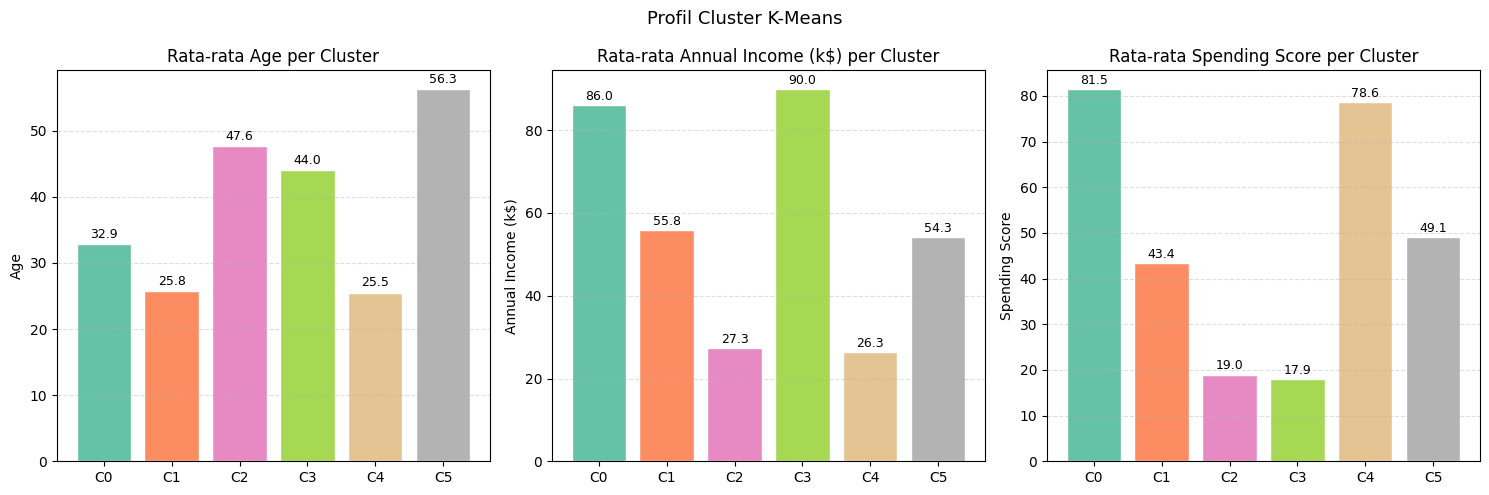

In [ ]:
df_profile = df.copy()
df_profile['annual_income'] = df_profile['annual_income'].clip(upper=132)
df_profile['Cluster'] = labels_kmeans

cluster_profile = df_profile.groupby('Cluster')[['age', 'annual_income', 'spending_score']].mean().round(2)

print("=== Rata-rata Fitur per Cluster ===")
print()
print(cluster_profile.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
feature_titles = ['Age', 'Annual Income (k$)', 'Spending Score']
raw_features = ['age', 'annual_income', 'spending_score']

for idx, (feat, title) in enumerate(zip(raw_features, feature_titles)):
    means = [df_profile[df_profile['Cluster'] == c][feat].mean()
             for c in range(k_optimal)]
    bars = axes[idx].bar(
        [f'C{i}' for i in range(k_optimal)],
        means,
        color=plt.cm.Set2(np.linspace(0, 1, k_optimal)),
        edgecolor='white'
    )
    axes[idx].set_title(f'Rata-rata {title} per Cluster')
    axes[idx].set_ylabel(title)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.4)
    for bar, val in zip(bars, means):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Profil Cluster K-Means', fontsize=13)
plt.tight_layout()
plt.show()

##5) Model DBSCAN

###K-Distance Graph untuk Estimasi Nilai eps

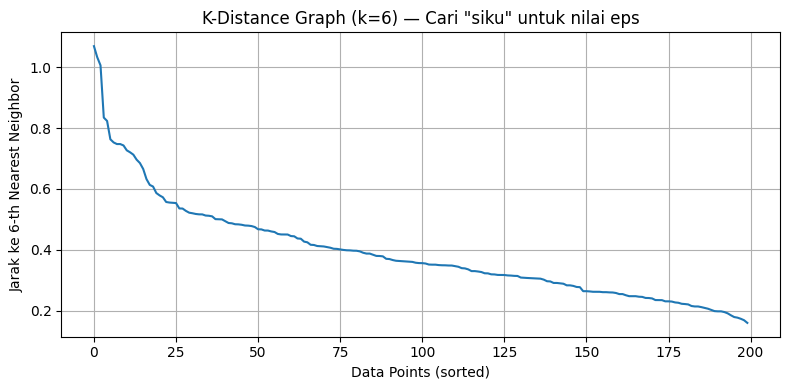

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

k_nn = 6

nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_dbscan)
distances, _ = nbrs.kneighbors(X_dbscan)
k_distances = np.sort(distances[:, k_nn - 1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title(f'K-Distance Graph (k={k_nn}) — Cari "siku" untuk nilai eps')
plt.xlabel('Data Points (sorted)')
plt.ylabel(f'Jarak ke {k_nn}-th Nearest Neighbor')
plt.grid(True)
plt.tight_layout()
plt.show()

###Optimasi Parameter eps dan min_samples

In [ ]:
eps_values         = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2]
min_samples_values = [3, 4, 5, 6, 8, 10]

results = []
for eps in eps_values:
    for min_s in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=min_s).fit_predict(X_dbscan)
        n_clusters  = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise     = np.sum(labels == -1)
        noise_ratio = n_noise / len(labels)
        sil = silhouette_score(X_dbscan, labels) if n_clusters >= 2 and n_noise < len(labels) else -1

        results.append({
            'eps': eps, 'min_samples': min_s,
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'noise_ratio': round(noise_ratio, 3),
            'silhouette': round(sil, 4)
        })

results_df = pd.DataFrame(results)
print("kombinasi terbaik (silhouette tertinggi, minimal 2 cluster):")
print()
print(results_df[results_df['n_clusters'] >= 2]
      .sort_values('silhouette', ascending=False)
      .head(10).to_string(index=False))

kombinasi terbaik (silhouette tertinggi, minimal 2 cluster):

 eps  min_samples  n_clusters  n_noise  noise_ratio  silhouette
 0.4           10           4       72        0.360      0.2590
 0.4            8           5       56        0.280      0.2375
 0.4            3           3       14        0.070      0.1802
 0.3            3           9       53        0.265      0.1763
 0.3            4           7       66        0.330      0.1761
 0.5           10           2       38        0.190      0.1578
 0.4            5           3       31        0.155      0.1237
 0.3            6           5       95        0.475      0.1158
 0.3            5           6       82        0.410      0.1112
 0.4            6           3       50        0.250      0.1093


###Pelatihan Model DBSCAN dengan Parameter Optimal

In [ ]:
best_eps         = 0.4
best_min_samples = 10

dbscan_final  = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_dbscan = dbscan_final.fit_predict(X_dbscan)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db    = np.sum(labels_dbscan == -1)
sil_db        = silhouette_score(X_dbscan, labels_dbscan)
db_db         = davies_bouldin_score(X_dbscan, labels_dbscan)
ch_db         = calinski_harabasz_score(X_dbscan, labels_dbscan)

print(f"=== Metrik DBSCAN ===")
print()
print(f"Jumlah Cluster         : {n_clusters_db}")
print(f"Noise Points           : {n_noise_db} ({n_noise_db/len(labels_dbscan)*100:.1f}%)")
print(f"Silhouette Score       : {sil_db:.4f}")
print(f"Davies-Bouldin Index   : {db_db:.4f}")
print(f"Calinski-Harabasz Index: {ch_db:.4f}")

=== Metrik DBSCAN ===

Jumlah Cluster         : 4
Noise Points           : 72 (36.0%)
Silhouette Score       : 0.2590
Davies-Bouldin Index   : 1.4566
Calinski-Harabasz Index: 44.6742


###Visualisasi Hasil Clustering DBSCAN

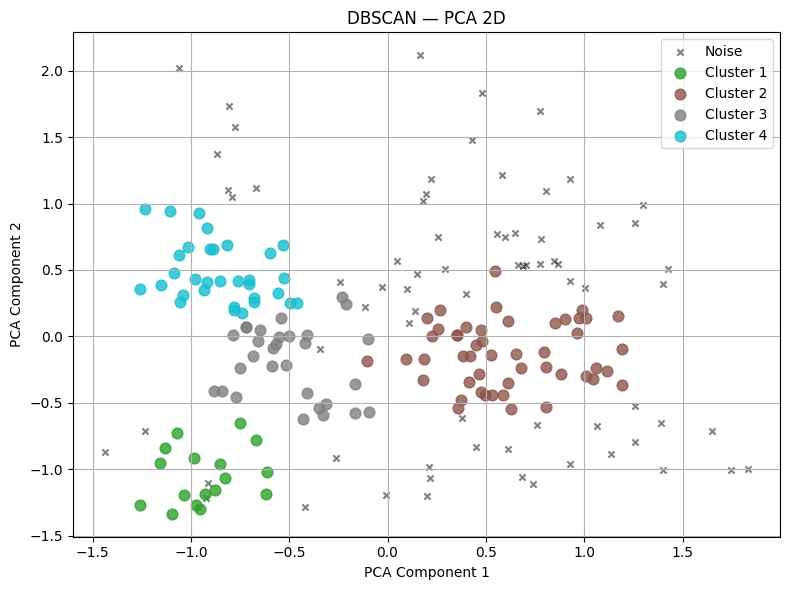

In [ ]:
pca_db   = PCA(n_components=2)
X_db_pca = pca_db.fit_transform(X_dbscan)

unique_labels = sorted(set(labels_dbscan))
cmap = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(8, 6))
for label, color in zip(unique_labels, cmap):
    mask = labels_dbscan == label
    if label == -1:
        plt.scatter(X_db_pca[mask, 0], X_db_pca[mask, 1],
                    c='black', s=20, marker='x', label='Noise', alpha=0.5)
    else:
        plt.scatter(X_db_pca[mask, 0], X_db_pca[mask, 1],
                    color=color, s=60, label=f'Cluster {label+1}', alpha=0.8)

plt.title(f'DBSCAN — PCA 2D')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Profil Tiap Cluster

=== Rata-rata Fitur per Cluster DBSCAN ===

           age  annual_income  spending_score
cluster                                      
0        24.06          25.00           76.71
1        54.63          54.04           48.59
2        24.33          55.03           49.47
3        32.62          80.38           82.94


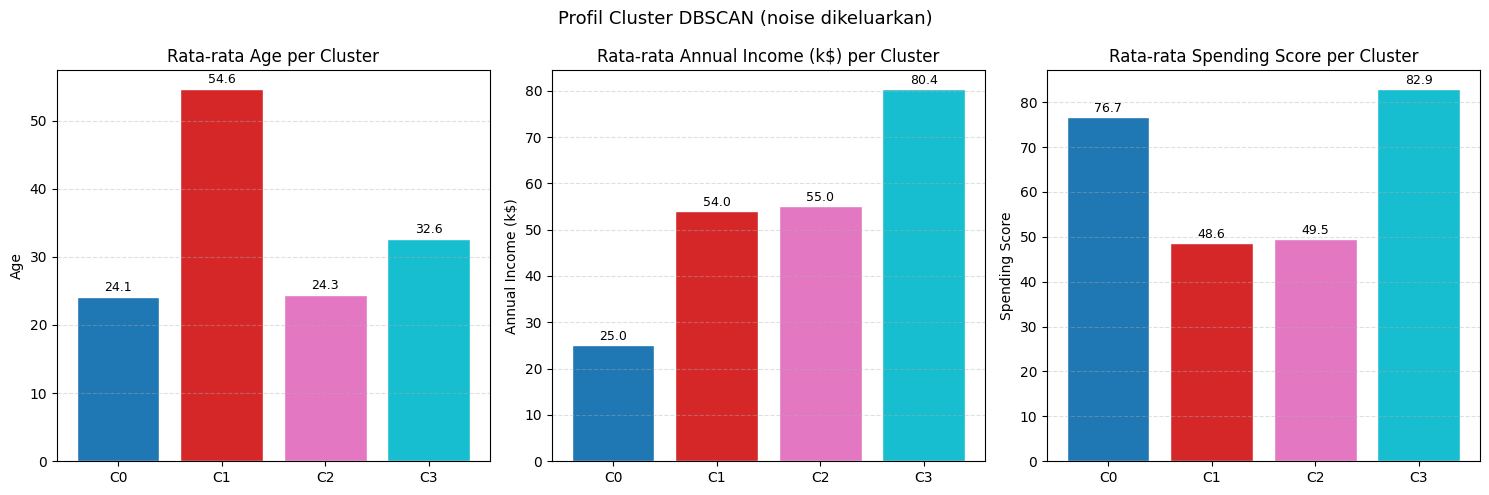

In [ ]:
df_profile_db = df[['age', 'annual_income', 'spending_score']].copy()
df_profile_db['cluster'] = labels_dbscan

cluster_profile_db = df_profile_db[df_profile_db['cluster'] != -1] \
    .groupby('cluster')[['age', 'annual_income', 'spending_score']].mean().round(2)

print("=== Rata-rata Fitur per Cluster DBSCAN ===")
print()
print(cluster_profile_db.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
feature_titles = ['Age', 'Annual Income (k$)', 'Spending Score']
raw_features = ['age', 'annual_income', 'spending_score']

df_profile_db_clean = df_profile_db[df_profile_db['cluster'] != -1]

for idx, (feat, title) in enumerate(zip(raw_features, feature_titles)):
    means = [df_profile_db_clean[df_profile_db_clean['cluster'] == c][feat].mean()
             for c in range(n_clusters_db)]
    bars = axes[idx].bar(
        [f'C{i}' for i in range(n_clusters_db)], means, color=plt.cm.tab10(np.linspace(0, 1, n_clusters_db)),edgecolor='white'
    )
    axes[idx].set_title(f'Rata-rata {title} per Cluster')
    axes[idx].set_ylabel(title)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.4)
    for bar, val in zip(bars, means):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Profil Cluster DBSCAN (noise dikeluarkan)', fontsize=13)
plt.tight_layout()
plt.show()

###Perbandingan DBSCAN vs K-Means

In [ ]:
print("=" * 55)
print(f"{'Metrik':<28} {'K-Means':>12} {'DBSCAN':>12}")
print("=" * 55)
print(f"{'Jumlah Cluster':<28} {k_optimal:>12} {n_clusters_db:>12}")
print(f"{'Noise Points':<28} {'N/A':>12} {n_noise_db:>12}")
print(f"{'Silhouette Score':<28} {sil_km:>12.4f} {sil_db:>12.4f}")
print(f"{'Davies-Bouldin Index':<28} {db_km:>12.4f} {db_db:>12.4f}")
print(f"{'Calinski-Harabasz Index':<28} {ch_km:>12.1f} {ch_db:>12.1f}")
print("=" * 55)

Metrik                            K-Means       DBSCAN
Jumlah Cluster                          6            4
Noise Points                          N/A           72
Silhouette Score                   0.4258       0.2590
Davies-Bouldin Index               0.8511       1.4566
Calinski-Harabasz Index             134.7         44.7


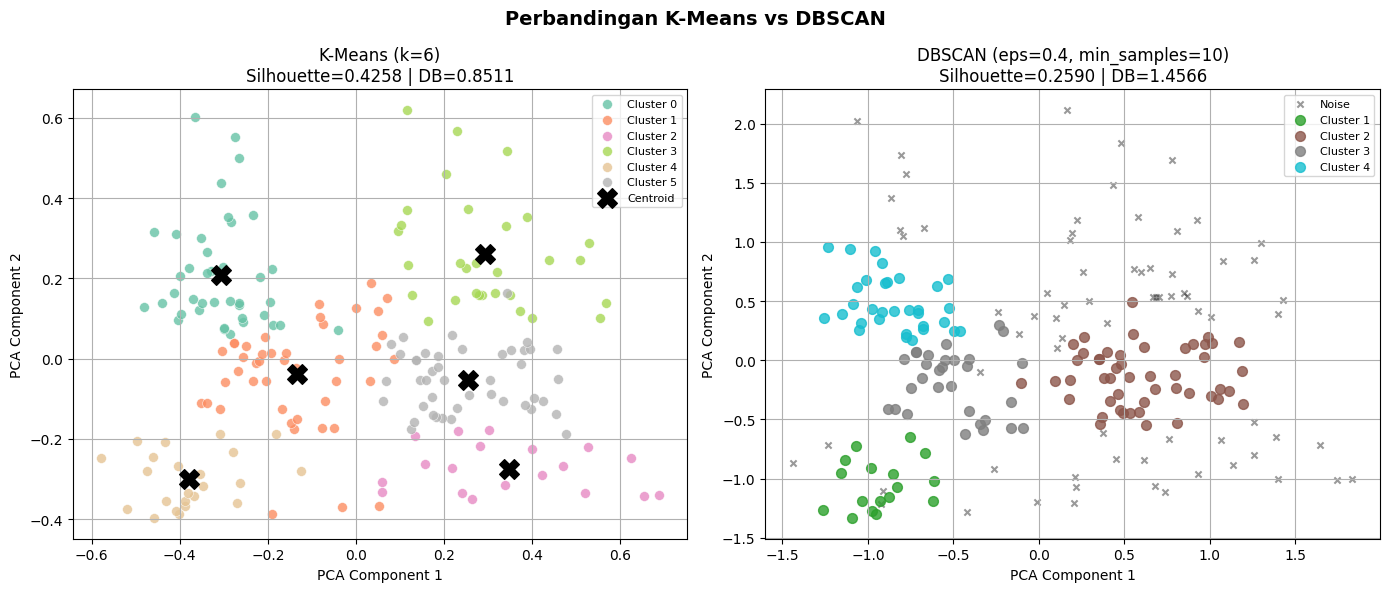

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

unique_labels_km = sorted(set(labels_kmeans))
cmap_km = plt.cm.Set2(np.linspace(0, 1, len(unique_labels_km)))

for label, color in zip(unique_labels_km, cmap_km):
    mask = labels_kmeans == label
    axes[0].scatter(X_km_pca[mask, 0], X_km_pca[mask, 1], color=color, s=50, label=f'Cluster {label}', alpha=0.8, edgecolors='white', linewidths=0.4)

axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=200, zorder=5, label='Centroid')
axes[0].set_title(f'K-Means (k={k_optimal})\n' f'Silhouette={sil_km:.4f} | DB={db_km:.4f}')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].legend(fontsize=8)
axes[0].grid(True)

unique_labels_db = sorted(set(labels_dbscan))
cmap_db = plt.cm.tab10(np.linspace(0, 1, len(unique_labels_db)))

for label, color in zip(unique_labels_db, cmap_db):
    mask = labels_dbscan == label
    if label == -1:
        axes[1].scatter(X_db_pca[mask, 0], X_db_pca[mask, 1], c='black', s=20, marker='x', label='Noise', alpha=0.4)
    else:
        axes[1].scatter(X_db_pca[mask, 0], X_db_pca[mask, 1], color=color, s=50, label=f'Cluster {label+1}', alpha=0.8)

axes[1].set_title(f'DBSCAN (eps={best_eps}, min_samples={best_min_samples})\n'
                  f'Silhouette={sil_db:.4f} | DB={db_db:.4f}')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.suptitle('Perbandingan K-Means vs DBSCAN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##6) Evaluasi dan Analisis

###Evaluasi K-MEANS dan DBSCAN

In [ ]:
import pandas as pd
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

print("===== EVALUASI K-MEANS =====")

n_clusters_km = k_optimal
sil_km = silhouette_score(X_kmeans, labels_kmeans)
db_km  = davies_bouldin_score(X_kmeans, labels_kmeans)
ch_km  = calinski_harabasz_score(X_kmeans, labels_kmeans)

print(f"Jumlah Cluster         : {n_clusters_km}")
print(f"Silhouette Score       : {sil_km:.4f}")
print(f"Davies-Bouldin Index   : {db_km:.4f}")
print(f"Calinski-Harabasz Index: {ch_km:.4f}")

print("\n===== EVALUASI DBSCAN =====")

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db    = np.sum(labels_dbscan == -1)

sil_db = silhouette_score(X_dbscan, labels_dbscan)
db_db  = davies_bouldin_score(X_dbscan, labels_dbscan)
ch_db  = calinski_harabasz_score(X_dbscan, labels_dbscan)

print(f"Jumlah Cluster         : {n_clusters_db}")
print(f"Noise Points           : {n_noise_db}")
print(f"Silhouette Score       : {sil_db:.4f}")
print(f"Davies-Bouldin Index   : {db_db:.4f}")
print(f"Calinski-Harabasz Index: {ch_db:.4f}")


===== EVALUASI K-MEANS =====
Jumlah Cluster         : 6
Silhouette Score       : 0.4258
Davies-Bouldin Index   : 0.8511
Calinski-Harabasz Index: 134.7462

===== EVALUASI DBSCAN =====
Jumlah Cluster         : 4
Noise Points           : 72
Silhouette Score       : 0.2590
Davies-Bouldin Index   : 1.4566
Calinski-Harabasz Index: 44.6742


###Perbandingan Model

In [ ]:
print("\n===== PERBANDINGAN MODEL =====")

print("=" * 55)
print(f"{'Metrik':<28} {'K-Means':>12} {'DBSCAN':>12}")
print("=" * 55)
print(f"{'Jumlah Cluster':<28} {n_clusters_km:>12} {n_clusters_db:>12}")
print(f"{'Noise Points':<28} {'N/A':>12} {n_noise_db:>12}")
print(f"{'Silhouette Score':<28} {sil_km:>12.4f} {sil_db:>12.4f}")
print(f"{'Davies-Bouldin Index':<28} {db_km:>12.4f} {db_db:>12.4f}")
print(f"{'Calinski-Harabasz Index':<28} {ch_km:>12.1f} {ch_db:>12.1f}")
print("=" * 55)


===== PERBANDINGAN MODEL =====
Metrik                            K-Means       DBSCAN
Jumlah Cluster                          6            4
Noise Points                          N/A           72
Silhouette Score                   0.4258       0.2590
Davies-Bouldin Index               0.8511       1.4566
Calinski-Harabasz Index             134.7         44.7


###Analisis Karakteristik Cluster K-MEANS

In [ ]:
print("\n===== RATA-RATA TIAP CLUSTER =====")
cluster_mean = df_profile.groupby('Cluster')[['age', 'annual_income', 'spending_score']].mean()
print(cluster_mean)

print("\n===== MEDIAN TIAP CLUSTER =====")
cluster_median = df_profile.groupby('Cluster')[['age', 'annual_income', 'spending_score']].median()
print(cluster_median)



===== RATA-RATA TIAP CLUSTER =====
               age  annual_income  spending_score
Cluster                                          
0        32.875000      85.975000       81.525000
1        25.767442      55.767442       43.372093
2        47.631579      27.315789       19.000000
3        44.000000      89.966667       17.933333
4        25.521739      26.304348       78.565217
5        56.333333      54.266667       49.066667

===== MEDIAN TIAP CLUSTER =====
          age  annual_income  spending_score
Cluster                                     
0        32.0           78.5            83.0
1        25.0           60.0            47.0
2        48.0           28.0            15.0
3        43.5           87.0            16.5
4        24.0           25.0            77.0
5        54.0           54.0            49.0


###Interpretasi Cluster K-MEANS

In [ ]:
print("\n===== INTERPRETASI CLUSTER =====")

for i in cluster_mean.index:

    age = cluster_mean.loc[i, 'age']
    income = cluster_mean.loc[i, 'annual_income']
    spending = cluster_mean.loc[i, 'spending_score']

    print(f"\nCluster {i}")
    print(f"Rata-rata umur           : {age:.2f}")
    print(f"Rata-rata pendapatan     : {income:.2f}")
    print(f"Rata-rata spending score : {spending:.2f}")

    if income > 70 and spending > 70:
        print("Karakteristik: Pelanggan premium dan aktif berbelanja.")

    elif income > 70 and spending < 40:
        print("Karakteristik: Pendapatan tinggi tetapi jarang belanja.")

    elif income < 40 and spending > 60:
        print("Karakteristik: Pendapatan rendah namun konsumtif.")

    elif spending < 40:
        print("Karakteristik: Cenderung hemat atau jarang berbelanja.")

    else:
        print("Karakteristik: Pelanggan dengan perilaku belanja sedang.")


===== INTERPRETASI CLUSTER =====

Cluster 0
Rata-rata umur           : 32.88
Rata-rata pendapatan     : 85.97
Rata-rata spending score : 81.53
Karakteristik: Pelanggan premium dan aktif berbelanja.

Cluster 1
Rata-rata umur           : 25.77
Rata-rata pendapatan     : 55.77
Rata-rata spending score : 43.37
Karakteristik: Pelanggan dengan perilaku belanja sedang.

Cluster 2
Rata-rata umur           : 47.63
Rata-rata pendapatan     : 27.32
Rata-rata spending score : 19.00
Karakteristik: Cenderung hemat atau jarang berbelanja.

Cluster 3
Rata-rata umur           : 44.00
Rata-rata pendapatan     : 89.97
Rata-rata spending score : 17.93
Karakteristik: Pendapatan tinggi tetapi jarang belanja.

Cluster 4
Rata-rata umur           : 25.52
Rata-rata pendapatan     : 26.30
Rata-rata spending score : 78.57
Karakteristik: Pendapatan rendah namun konsumtif.

Cluster 5
Rata-rata umur           : 56.33
Rata-rata pendapatan     : 54.27
Rata-rata spending score : 49.07
Karakteristik: Pelanggan dengan p

###Analisis Karakteristik Cluster DBSCAN

In [ ]:
cluster_profile_db = df_profile_db[df_profile_db['cluster'] != -1] \
    .groupby('cluster')[['age', 'annual_income', 'spending_score']].mean().round(2)

print("=== Rata-rata Fitur per Cluster DBSCAN ===")
print()
print(cluster_profile_db.to_string())

cluster_median_db = df_profile_db[df_profile_db['cluster'] != -1] \
    .groupby('cluster')[['age', 'annual_income', 'spending_score']].median().round(2)

print("=== Median Fitur per Cluster DBSCAN ===")
print()
print(cluster_median_db.to_string())

=== Rata-rata Fitur per Cluster DBSCAN ===

           age  annual_income  spending_score
cluster                                      
0        24.06          25.00           76.71
1        54.63          54.04           48.59
2        24.33          55.03           49.47
3        32.62          80.38           82.94
=== Median Fitur per Cluster DBSCAN ===

          age  annual_income  spending_score
cluster                                     
0        23.0           24.0            76.0
1        51.0           54.0            48.0
2        23.5           58.0            50.5
3        32.0           78.0            86.0


###Interpretasi Cluster DBSCAN

In [ ]:
print("===== INTERPRETASI CLUSTER DBSCAN =====")

interpretasi_db = {
    0: ("Young Low-Income Impulsive Spender",
        "Pelanggan muda dengan pendapatan rendah namun konsumtif dan impulsif dalam berbelanja."),
    1: ("Mature Average Spender",
        "Pelanggan berusia dewasa-tua dengan pendapatan menengah dan pola belanja yang terencana dan moderat."),
    2: ("Young Mid-Income Moderate Spender",
        "Pelanggan muda dengan pendapatan menengah namun tidak berbelanja secara berlebihan."),
    3: ("Young High-Income Premium Spender",
        "Pelanggan muda-dewasa berpendapatan tinggi dan aktif berbelanja — segmen paling bernilai secara bisnis.")
}

for i, row in cluster_profile_db.iterrows():
    label, deskripsi = interpretasi_db[i]
    print(f"\nCluster {i}")
    print(f"  Usia rata-rata    : {row['age']:.2f} tahun")
    print(f"  Pendapatan        : {row['annual_income']:.2f} k$")
    print(f"  Spending score    : {row['spending_score']:.2f}")
    print(f"  Karakteristik     : {deskripsi}")

print(f"\nNoise Points (72 pelanggan, 36%)")
print(f"  Karakteristik     : Pelanggan dengan pola perilaku yang terlalu beragam")
print(f"                      untuk membentuk cluster tersendiri, umumnya berpendapatan")
print(f"                      menengah-tinggi namun spending score rendah.")

===== INTERPRETASI CLUSTER DBSCAN =====

Cluster 0
  Usia rata-rata    : 24.06 tahun
  Pendapatan        : 25.00 k$
  Spending score    : 76.71
  Karakteristik     : Pelanggan muda dengan pendapatan rendah namun konsumtif dan impulsif dalam berbelanja.

Cluster 1
  Usia rata-rata    : 54.63 tahun
  Pendapatan        : 54.04 k$
  Spending score    : 48.59
  Karakteristik     : Pelanggan berusia dewasa-tua dengan pendapatan menengah dan pola belanja yang terencana dan moderat.

Cluster 2
  Usia rata-rata    : 24.33 tahun
  Pendapatan        : 55.03 k$
  Spending score    : 49.47
  Karakteristik     : Pelanggan muda dengan pendapatan menengah namun tidak berbelanja secara berlebihan.

Cluster 3
  Usia rata-rata    : 32.62 tahun
  Pendapatan        : 80.38 k$
  Spending score    : 82.94
  Karakteristik     : Pelanggan muda-dewasa berpendapatan tinggi dan aktif berbelanja — segmen paling bernilai secara bisnis.

Noise Points (72 pelanggan, 36%)
  Karakteristik     : Pelanggan dengan pola pe

###